### Imports

In [1]:
import os, sys

# Go to the repo root (adjust path if needed)
%cd /content/Data-Science-Project

# Make sure repo root is on sys.path
repo_root = os.getcwd()
if repo_root not in sys.path:
    sys.path.append(repo_root)

print("Using repo_root:", repo_root)

/content/Data-Science-Project
Using repo_root: /content/Data-Science-Project


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from data.kaggle_text import load_kaggle_disaster_csv
from models.text_branch import create_text_classifier, TextDatasetWrapper, TextClassificationWrapper
from training.utils import train_one_epoch, evaluate, seed_everything

### Load and tokenize Kaggle dataset

In [3]:
seed_everything(42)

# Load Kaggle disaster tweets as a HuggingFace Dataset
hf_dataset = load_kaggle_disaster_csv("../train.csv")  # adjust path if needed

# 80/20 split with fixed seed for reproducibility
hf_dataset = hf_dataset.train_test_split(test_size=0.2, seed=42)
train_ds_raw = hf_dataset["train"]
val_ds_raw   = hf_dataset["test"]

# Create model & tokenizer
model_hf, tokenizer = create_text_classifier(num_labels=2)

# Tokenization function
def tokenize_batch(batch):
    out = tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128,
    )
    out["label"] = batch["label"]
    return out

tokenized = hf_dataset.map(tokenize_batch, batched=True)
train_ds_tok = tokenized["train"]
val_ds_tok   = tokenized["test"]

# Keep only the needed columns and set PyTorch format
columns = ["input_ids", "attention_mask", "label"]
train_ds_tok.set_format(type="torch", columns=columns)
val_ds_tok.set_format(type="torch", columns=columns)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/6090 [00:00<?, ? examples/s]

Map:   0%|          | 0/1523 [00:00<?, ? examples/s]

### Wrap dataset

In [4]:
# Wrap the HF datasets so each batch is: ((input_ids, attention_mask), label)

train_wrapped = TextDatasetWrapper(train_ds_tok)
val_wrapped   = TextDatasetWrapper(val_ds_tok)

train_loader = DataLoader(train_wrapped, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_wrapped,   batch_size=16, shuffle=False)

### Wrap model

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TextClassificationWrapper(model_hf).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

EPOCHS = 10

train_loss_hist = []
train_acc_hist  = []
val_loss_hist   = []
val_acc_hist    = []

print(f"Using device: {device}")

Using device: cuda


### Training loop

In [7]:
best_val_loss = float("inf")
best_state_dict = None

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # train_one_epoch and evaluate are imported from training/utils.py.
    # They expect each batch to be (inputs, labels), where `inputs` is a tuple.
    train_loss, train_acc = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    val_loss, val_acc, _, _, _ = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
    )

    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

    # Track best epoch
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = model.state_dict().copy()

print("\nTraining complete.")



Epoch 1/10


train_loss=0.4355, train_acc=0.8090, val_loss=0.3826, val_acc=0.8444

Epoch 2/10


train_loss=0.3143, train_acc=0.8777, val_loss=0.4060, val_acc=0.8385

Epoch 3/10


train_loss=0.2167, train_acc=0.9186, val_loss=0.5635, val_acc=0.7899

Epoch 4/10


train_loss=0.1425, train_acc=0.9466, val_loss=0.5259, val_acc=0.8234

Epoch 5/10


...

train_loss=0.0737, train_acc=0.9700, val_loss=0.7489, val_acc=0.8122

Epoch 7/10


train_loss=0.0613, train_acc=0.9734, val_loss=0.8319, val_acc=0.8004

Epoch 8/10


train_loss=0.0550, train_acc=0.9764, val_loss=0.8126, val_acc=0.7951

Epoch 9/10


train_loss=0.0540, train_acc=0.9770, val_loss=0.8799, val_acc=0.8109

Epoch 10/10


train_loss=0.0515, train_acc=0.9772, val_loss=0.9032, val_acc=0.8194

Training complete.


### Save model and tokenizer

In [8]:
os.makedirs("../checkpoints/text_branch", exist_ok=True)

# Load best weights before saving
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

# Save model and tokenizer
model_hf.save_pretrained("../checkpoints/text_branch")
tokenizer.save_pretrained("../checkpoints/text_branch")

print("Saved text model and tokenizer to ../checkpoints/text_branch")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved text model and tokenizer to ../checkpoints/text_branch


### Plot training/eval metrics

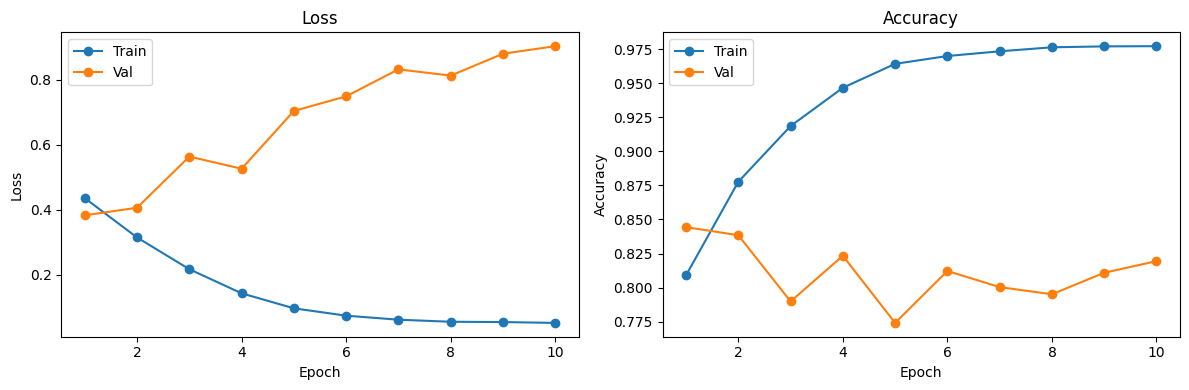

In [9]:
epochs = np.arange(1, EPOCHS + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
ax[0].plot(epochs, train_loss_hist, marker="o", label="Train")
ax[0].plot(epochs, val_loss_hist,   marker="o", label="Val")
ax[0].set_title("Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

# Accuracy curves
ax[1].plot(epochs, train_acc_hist, marker="o", label="Train")
ax[1].plot(epochs, val_acc_hist,   marker="o", label="Val")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()

plt.tight_layout()
plt.show()

### Evaluation on validation set


--- DISTILBERT TEXT MODEL VALIDATION RESULTS ---
Val Accuracy: 81.94%
Val F1 Score: 0.7777
Val ROC AUC:  0.8654


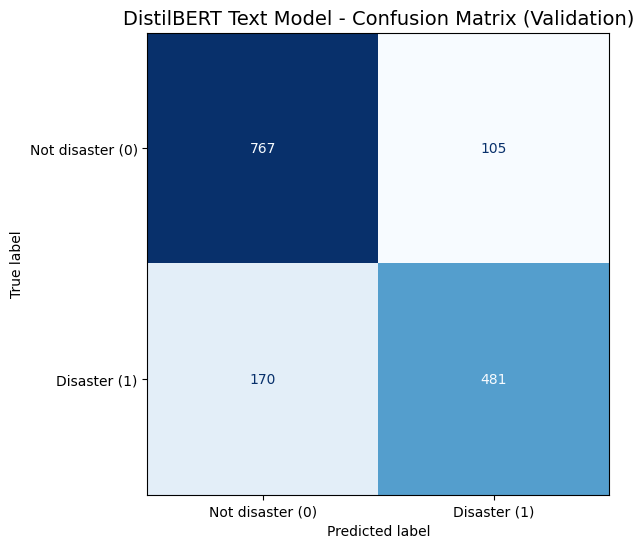

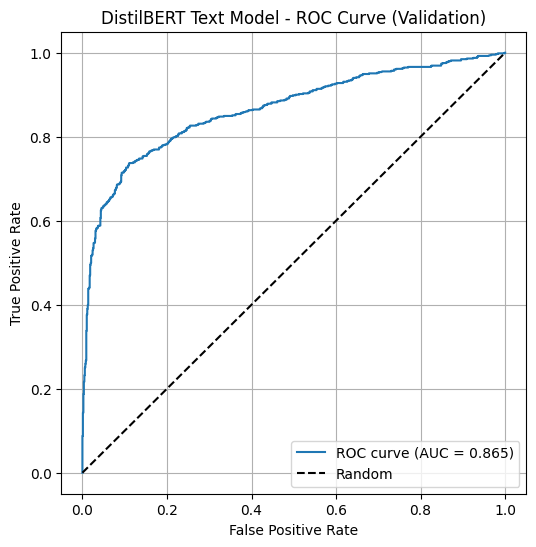

In [10]:
# Re-run evaluate to get predictions, or cache last val_preds/val_true if you prefer
val_loss, val_acc, val_preds, val_true, val_probs = evaluate(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=device,
)

val_f1  = f1_score(val_true, val_preds, average="binary")
val_auc = roc_auc_score(val_true, val_probs)

print("\n--- DISTILBERT TEXT MODEL VALIDATION RESULTS ---")
print(f"Val Accuracy: {val_acc * 100:.2f}%")
print(f"Val F1 Score: {val_f1:.4f}")
print(f"Val ROC AUC:  {val_auc:.4f}")

# Build confusion matrix
cm = confusion_matrix(val_true, val_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not disaster (0)", "Disaster (1)"])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", ax=ax, colorbar=False)
plt.title("DistilBERT Text Model - Confusion Matrix (Validation)", fontsize=14)
plt.grid(False)
plt.show()

# Build ROC curve
fpr, tpr, thresholds = roc_curve(val_true, val_probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {val_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("DistilBERT Text Model - ROC Curve (Validation)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

